In [39]:
import pandas as pd

data = pd.read_csv('day18_full_review.csv')

data.head()

,customer_id,order_datetime,age,region,channel,membership_level,visit_count,session_time_min,cart_value,discount_pct,payment_method,campaign,order_amount
0,C00001,2026-06-13 09:00:00,48.0,Gwangju,web,silver,8,18.9,182.3,20,card,none,194.3
1,C00002,2026-01-07 16:00:00,52.0,Daegu,web,silver,9,26.6,72.5,15,card,summer,114.2
2,C00003,2026-03-29 12:00:00,55.0,Daegu,app,silver,16,15.4,123.1,0,card,summer,150.6
3,C00004,2026-04-07 09:00:00,31.0,Busan,store,basic,1,12.8,34.8,15,mobile,none,47.0
4,C00005,2026-03-16 09:00:00,53.0,Busan,app,basic,1,11.4,141.1,5,mobile,none,163.9


In [40]:
print(data.shape)
print(data.isnull().sum())

(435, 13)
customer_id          0
order_datetime       0
age                 15
region              12
channel              0
membership_level     0
visit_count          0
session_time_min    18
cart_value          15
discount_pct         0
payment_method      10
campaign             0
order_amount         0
dtype: int64


In [41]:
data.describe()

,age,visit_count,cart_value,discount_pct,order_amount
count,420.000000,435.000000,420.000000,435.000000,435.000000
mean,38.526190,7.896552,109.958810,9.057471,142.678391
std,11.627134,4.071466,67.029586,7.689775,44.174569
min,18.000000,1.000000,5.000000,0.000000,19.600000
25%,30.000000,5.000000,69.075000,0.000000,111.700000
50%,39.000000,8.000000,105.550000,10.000000,143.400000
75%,46.250000,11.000000,139.150000,15.000000,172.600000
max,76.000000,21.000000,518.700000,20.000000,254.100000


In [42]:
data.isnull().sum().sum()

np.int64(70)

In [43]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       435 non-null    str    
 1   order_datetime    435 non-null    str    
 2   age               420 non-null    float64
 3   region            423 non-null    str    
 4   channel           435 non-null    str    
 5   membership_level  435 non-null    str    
 6   visit_count       435 non-null    int64  
 7   session_time_min  417 non-null    str    
 8   cart_value        420 non-null    float64
 9   discount_pct      435 non-null    int64  
 10  payment_method    425 non-null    str    
 11  campaign          435 non-null    str    
 12  order_amount      435 non-null    float64
dtypes: float64(3), int64(2), str(8)
memory usage: 44.3 KB


In [44]:
data['membership_level'].value_counts()

membership_level
basic     197
silver    152
gold       86
Name: count, dtype: int64

In [45]:
# session_time_min 숫자로 변환
data['session_time_min'] = pd.to_numeric(data['session_time_min'], errors='coerce') # errors='coerce' : 숫자로 못바꾸는 문자열은 nan
data['session_time_min'].dtype # 실수형으로 바뀜

dtype('float64')

In [46]:
# data['age'].fillna(data['age'].median(), inplace=True)
# data['session_time_min'].fillna(data['session_time_min'].median(), inplace=True)
# data['cart_value'].fillna(data['cart_value'].mean(), inplace=True)
# data['region'].fillna(data['region'].mode()[0], inplace=True)
# data['payment_method'].fillna(data['payment_method'].mode()[0], inplace=True )

# 꼭 inplace를 여러 개 써야하는 상황이라면, DataFrame 사용({})
data.fillna({
    'age':data['age'].median(),
    'session_time_min':data['session_time_min'].median(),
    'cart_value':data['cart_value'].mean(),
    'region':data['region'].mode()[0],
    'payment_method':data['payment_method'].mode()[0]
}, inplace=True)

data.isnull().sum()


customer_id         0
order_datetime      0
age                 0
region              0
channel             0
membership_level    0
visit_count         0
session_time_min    0
cart_value          0
discount_pct        0
payment_method      0
campaign            0
order_amount        0
dtype: int64

In [47]:
# 중복행 처리
data.duplicated().sum()
data.shape

(435, 13)

In [48]:
data.drop_duplicates(inplace=True)
print(data.shape)

(430, 13)


In [49]:
data.reset_index(drop=True, inplace=True) #drop=True를 하지 않으면 index 컬럼이 생긴다.

In [50]:
data['order_datetime'] = pd.to_datetime(data['order_datetime'])

data['order_year'] = data['order_datetime'].dt.year
data['order_month'] = data['order_datetime'].dt.month
data['order_day'] = data['order_datetime'].dt.day
data['order_hour'] = data['order_datetime'].dt.hour
data['order_dayofweek'] = data['order_datetime'].dt.dayofweek
data['is_weekend'] = data['order_dayofweek'].isin([5,6]).astype(int)

data.drop(columns='order_datetime', inplace=True)

In [51]:
data.head()

,customer_id,age,region,channel,membership_level,visit_count,session_time_min,cart_value,discount_pct,payment_method,campaign,order_amount,order_year,order_month,order_day,order_hour,order_dayofweek,is_weekend
0,C00001,48.0,Gwangju,web,silver,8,18.9,182.3,20,card,none,194.3,2026,6,13,9,5,1
1,C00002,52.0,Daegu,web,silver,9,26.6,72.5,15,card,summer,114.2,2026,1,7,16,2,0
2,C00003,55.0,Daegu,app,silver,16,15.4,123.1,0,card,summer,150.6,2026,3,29,12,6,1
3,C00004,31.0,Busan,store,basic,1,12.8,34.8,15,mobile,none,47.0,2026,4,7,9,1,0
4,C00005,53.0,Busan,app,basic,1,11.4,141.1,5,mobile,none,163.9,2026,3,16,9,0,0


In [52]:
data.rename(columns={'membership_level':'member_level'}, inplace=True)

In [53]:
data.rename(columns={'order_amount':'target_amount'}, inplace=True)
# 값 기준 정렬
data.sort_values('target_amount', ascending=False, inplace=True)

In [54]:

# 주문 금액이 가장 큰 값을 가진 사용자 아이디 / 여기서 id 빼면 가장 주문 금액이 높은 행 확인
# 사실상 이미 내림차순 정렬 해서 data.iloc[0]도 가능함
print(data.loc[data['target_amount'].idxmax(), 'customer_id'])
print(data.loc[data['target_amount'].idxmax()])

C00379
customer_id          C00379
age                    26.0
region              Daejeon
channel               store
member_level          basic
visit_count              14
session_time_min       17.0
cart_value            226.9
discount_pct             10
payment_method         card
campaign               none
target_amount         254.1
order_year             2026
order_month               5
order_day                30
order_hour               13
order_dayofweek           5
is_weekend                1
Name: 378, dtype: object


In [55]:
# iloc 조건
data.iloc[
    (data['region']=='Busan')&
    (data['target_amount']>=150)
    ][['customer_id', 'region', 'member_level', 'target_amount']]

# loc 조건
data.loc[
    (data['region']=='Busan')&
    (data['target_amount']>=150),
    ['customer_id', 'region', 'member_level', 'target_amount']
]

,customer_id,region,member_level,target_amount
406,C00407,Busan,gold,245.6
227,C00228,Busan,silver,230.3
200,C00201,Busan,basic,224.2
23,C00024,Busan,gold,221.2
354,C00355,Busan,silver,208.0
284,C00285,Busan,basic,200.8
299,C00300,Busan,silver,198.4
209,C00210,Busan,gold,194.8
120,C00121,Busan,gold,194.2
47,C00048,Busan,basic,192.8


In [56]:
# groupby 집계함수를 컬럼마다 다르게 설정 - agg 이용 - 키 밸류 형태로 들어감
region_summary = data.groupby('region').agg({
    'target_amount':'mean',
    'cart_value':'mean',
    'visit_count':'sum'
})
region_summary.sort_values('target_amount',ascending=False, inplace=True)

In [57]:
region_summary

,target_amount,cart_value,visit_count
region,,,
Seoul,145.956790,107.666884,650
Busan,144.063636,113.687232,704
Gwangju,142.764103,108.643513,685
Daegu,141.785185,117.561946,606
Daejeon,140.904902,105.105075,747


In [58]:
region_info = pd.DataFrame({
    'region': ['Seoul', 'Busan', 'Daegu', 'Daejeon', 'Gwangju'],
    'region_grade': ['A', 'A', 'B', 'B', 'C']
})

In [59]:
# merge() - on = 조인 컬럼명
data_merged = data.merge(region_info, on='region', how='left')
data_merged.isnull().sum()

customer_id         0
age                 0
region              0
channel             0
member_level        0
visit_count         0
session_time_min    0
cart_value          0
discount_pct        0
payment_method      0
campaign            0
target_amount       0
order_year          0
order_month         0
order_day           0
order_hour          0
order_dayofweek     0
is_weekend          0
region_grade        0
dtype: int64

In [60]:
# 양방향 concat
extra_rows = data.head(3).copy()
extra_rows['customer_id'] = ['NEW001', 'NEW002', 'NEW003']

In [61]:
extra_rows

,customer_id,age,region,channel,member_level,visit_count,session_time_min,cart_value,discount_pct,payment_method,campaign,target_amount,order_year,order_month,order_day,order_hour,order_dayofweek,is_weekend
378,NEW001,26.0,Daejeon,store,basic,14,17.0,226.9,10,card,none,254.1,2026,5,30,13,5,1
137,NEW002,41.0,Daejeon,app,silver,11,16.9,220.8,0,mobile,summer,247.4,2026,4,1,17,2,0
71,NEW003,46.0,Seoul,store,gold,6,16.0,210.9,10,transfer,vip,247.1,2026,5,22,8,4,0


In [62]:
data_concat_row = pd.concat([data, extra_rows], axis=0, ignore_index=True)


In [63]:
data_concat_row.shape

(433, 18)

In [64]:
extra_cols = pd.DataFrame({
    'score_a': range(len(data)),
    'score_b': range(1000, 1000 + len(data))
})

In [65]:
data_concat_col = pd.concat([data, extra_cols], axis=1)

In [66]:
data_concat_col.shape

(430, 20)

In [67]:
data['member_level'] = data['member_level'].map({
  'basic':0,
  'silver':1,
  'gold':2
})

data = pd.get_dummies(data, columns=['region', 'channel', 'payment_method', 'campaign'], dtype=int)


In [68]:
data.head()

,customer_id,age,member_level,visit_count,session_time_min,cart_value,discount_pct,target_amount,order_year,order_month,...,region_Seoul,channel_app,channel_store,channel_web,payment_method_card,payment_method_mobile,payment_method_transfer,campaign_none,campaign_summer,campaign_vip
378,C00379,26.0,0,14,17.0,226.9,10,254.1,2026,5,...,0,0,1,0,1,0,0,1,0,0
137,C00138,41.0,1,11,16.9,220.8,0,247.4,2026,4,...,0,1,0,0,0,1,0,0,1,0
71,C00072,46.0,2,6,16.0,210.9,10,247.1,2026,5,...,1,0,1,0,0,0,1,0,0,1
359,C00360,36.0,2,15,9.9,172.2,0,245.9,2026,4,...,0,0,1,0,0,1,0,1,0,0
406,C00407,53.0,2,12,17.1,187.4,10,245.6,2026,8,...,0,0,1,0,1,0,0,1,0,0


In [69]:
data.drop('customer_id', axis=1, inplace=True)

In [70]:
print(data.shape)
print(data.dtypes)

(430, 27)
age                        float64
member_level                 int64
visit_count                  int64
session_time_min           float64
cart_value                 float64
discount_pct                 int64
target_amount              float64
order_year                   int32
order_month                  int32
order_day                    int32
order_hour                   int32
order_dayofweek              int32
is_weekend                   int64
region_Busan                 int64
region_Daegu                 int64
region_Daejeon               int64
region_Gwangju               int64
region_Seoul                 int64
channel_app                  int64
channel_store                int64
channel_web                  int64
payment_method_card          int64
payment_method_mobile        int64
payment_method_transfer      int64
campaign_none                int64
campaign_summer              int64
campaign_vip                 int64
dtype: object


In [71]:
Q1 = data['cart_value'].quantile(0.25)
Q3 = data['cart_value'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [72]:
data[(data['cart_value']<lower)|(data['cart_value']>upper)].value_counts().sum()

np.int64(8)

In [73]:
data = data.drop(data[
  (data['cart_value']<lower)|
  (data['cart_value']>upper)
  ].index, axis=0)

In [74]:
data.shape

(422, 27)

In [ ]:
data.reset_index(drop=True, inplace=True) 
# reset_index 할때는 drop=True 하기 - 아니면 빈 인덱스명이 index로 남음

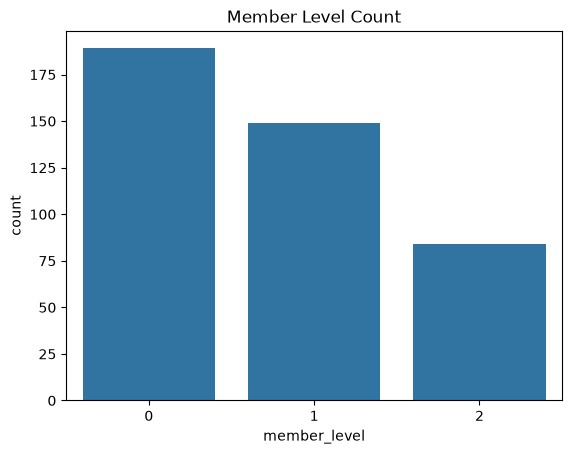

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=data, x='member_level')

plt.title('Member Level Count')

plt.show()

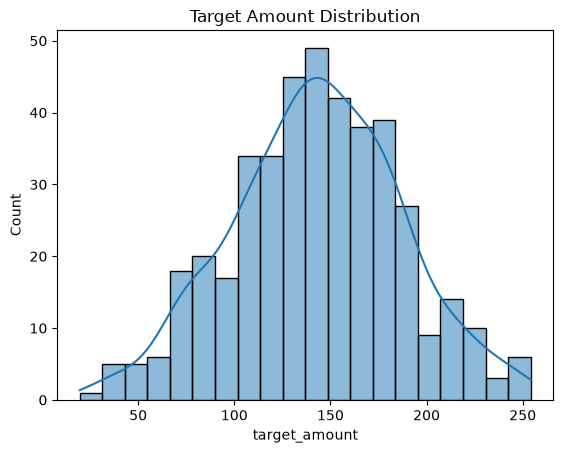

In [77]:
sns.histplot(data=data, x='target_amount', bins=20, kde=True)

plt.title('Target Amount Distribution')

plt.show()

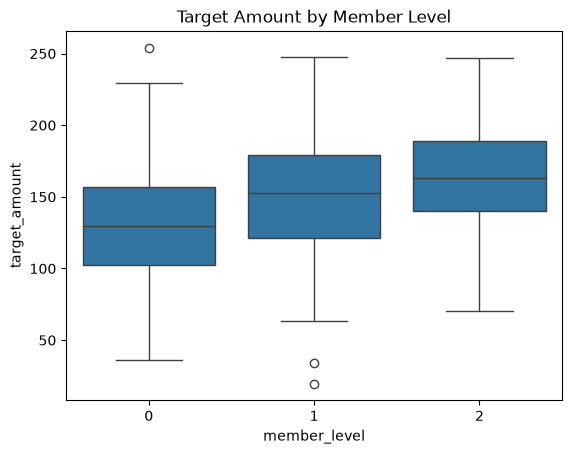

In [78]:
plt.figure()

sns.boxplot(data=data, x='member_level', y='target_amount')

plt.title('Target Amount by Member Level')

plt.show()


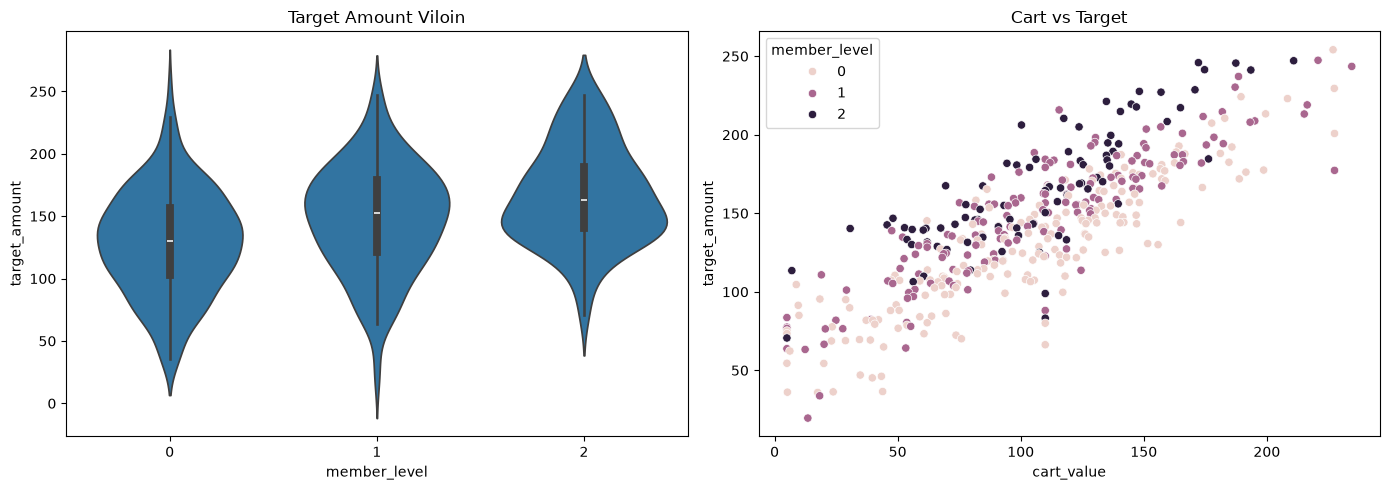

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=data, x='member_level', y='target_amount', ax=axes[0])

sns.scatterplot(data=data, x='cart_value', y='target_amount', hue='member_level', ax=axes[1])

axes[0].set_title('Target Amount Viloin')

axes[1].set_title('Cart vs Target')

# 레이아웃 빈 부분을 자연스럽게 정리해줌
plt.tight_layout()
plt.show()

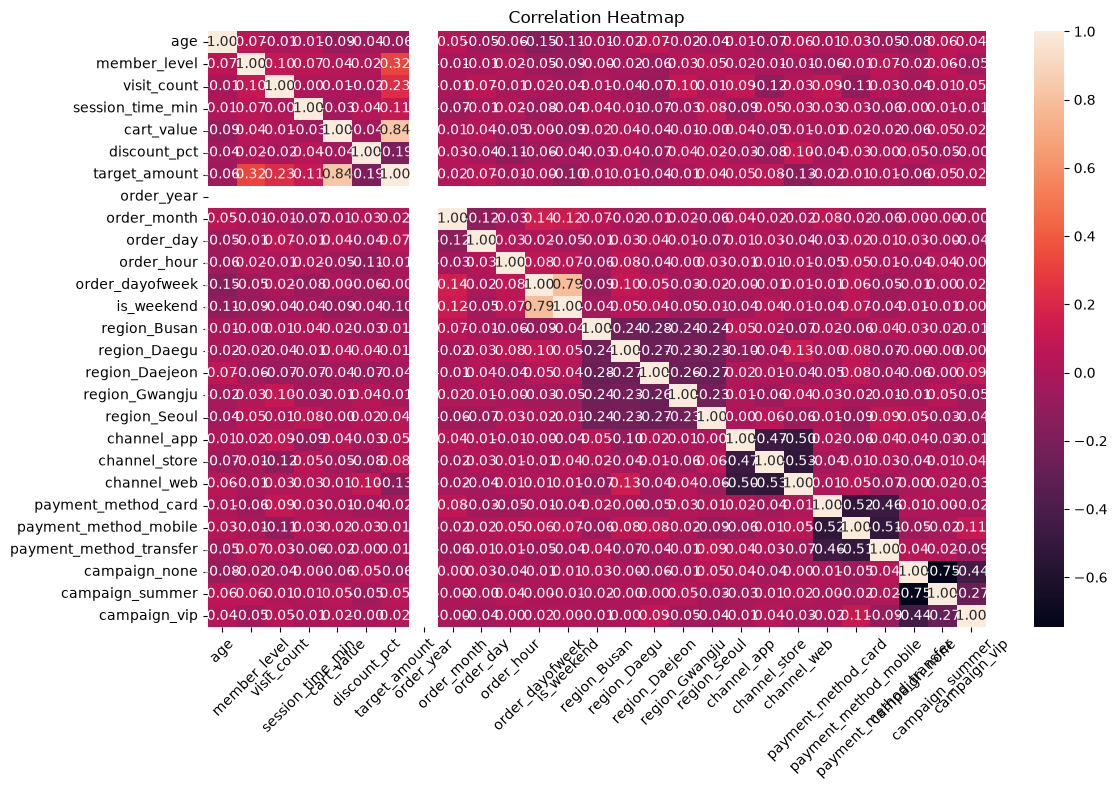

In [94]:
# 상관계수
corr = data.corr(numeric_only=True)
# 만약 select_dtypes를 요구한다면
# numeric_data = data.select_dtypes(include='number')
# corr = select_dtypes.corr()

plt.figure(figsize=(12, 8))

# annot -> 수치 넣어줄지
sns.heatmap(corr, annot=True, fmt='.2f')

# 그래프 하나일 때 x 컬럼명 돌리기
plt.xticks(rotation=45)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.show()


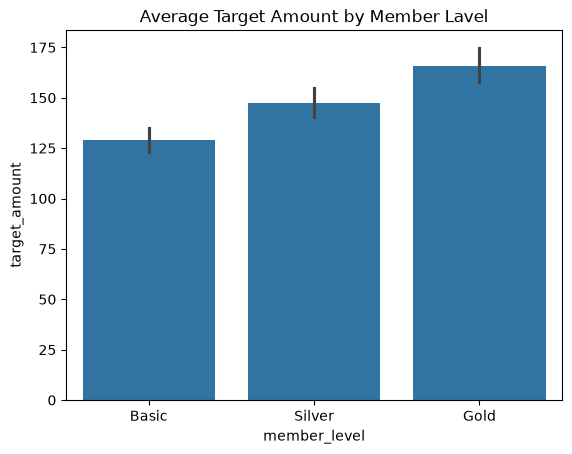

In [81]:
sns.barplot(data=data, x='member_level', y='target_amount')

# 라벨 명 바꾸기
plt.xticks(
  ticks=[0, 1, 2],
  labels=['Basic','Silver','Gold']
)

plt.title('Average Target Amount by Member Lavel')
plt.show()

In [82]:
from sklearn.model_selection import train_test_split

X = data.drop('target_amount', axis=1)
y = data['target_amount']

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  random_state=42,
  test_size=0.2
)

print(X_train.shape , X_test.shape , y_train.shape , y_test.shape)

(337, 26) (85, 26) (337,) (85,)


In [83]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()
rb_scaler = RobustScaler()

X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

X_train_rb = rb_scaler.fit_transform(X_train)
X_test_rb = rb_scaler.transform(X_test)

In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# tree - 원본 x_train, x_test
# 그 외 회귀(현재 범위) - x_train_std, x_test_std
lr = LinearRegression()
svr = SVR()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)

lr.fit(X_train_std, y_train)
svr.fit(X_train_std, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

lr_pred = lr.predict(X_test_std)
svr_pred = svr.predict(X_test_std)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_regression(y_test, pred):
  mae =  mean_absolute_error(y_test, pred)
  mse = mean_squared_error(y_test, pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, pred)

  print(f'mae : {mae}\nmse : {mse}\nrmse : {rmse}\nr2 : {r2}\n')

print('lr')
evaluate_regression( y_test, lr_pred)
print('svr')
evaluate_regression(y_test, svr_pred)
print('dt')
evaluate_regression(y_test, dt_pred)
print('rf')
evaluate_regression(y_test, rf_pred)

lr
mae : 11.088136165191383
mse : 195.8980677708879
rmse : 13.996359089809317
r2 : 0.9191195043316304

svr
mae : 38.05403618459195
mse : 2125.9885353399577
rmse : 46.108443210977725
r2 : 0.12224245761999175

dt
mae : 22.934117647058823
mse : 859.5588235294114
rmse : 29.318233635903294
r2 : 0.6451136833851359

rf
mae : 16.965588235294128
mse : 446.93541940000046
rmse : 21.140847177916037
r2 : 0.8154736355281467



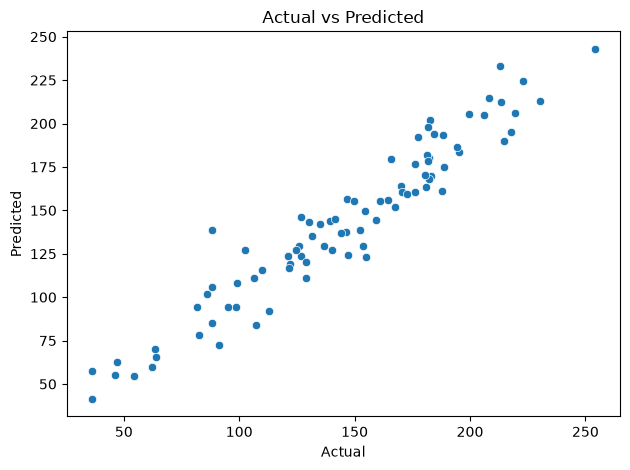

In [86]:
# 좋은 회귀모델 
# 실제 값과 예측값이 대각선 방향으로 가깝게 분포하므로 모델의 예측 성능이 비교적 좋다고 볼 수 있다.
sns.scatterplot(x=y_test, y=lr_pred)

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title('Actual vs Predicted')

plt.tight_layout()

plt.show()

In [87]:
# 교차검증 cross_val_score
from sklearn.model_selection import cross_val_score

lr_model = LinearRegression()

lr_model.fit(X_train_std, y_train)

scores = cross_val_score(
  lr_model,
  X_train_std,
  y_train,
  cv=5,
  scoring='r2'
)

# 교차검증 점수  
print(scores)
# 교차검증 점수 평균
print(scores.mean())

[0.89431047 0.89991587 0.80533305 0.80240808 0.82052307]
0.8444981110359212


In [88]:
# 최적의 하이퍼파라미터 찾기
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestRegressor(random_state=42)

params = {
  'n_estimators':[50, 100, 200],
  'max_depth':[None, 5, 10],
  'min_samples_split':[2, 5, 10]
}

grid_rf = GridSearchCV(
  rf_model,
  params,
  cv=5,
  scoring='r2',
  n_jobs=-1
)

grid_rf.fit(
  X_train,
  y_train
);

In [89]:
print(grid_rf.best_params_)
print(grid_rf.best_score_)
print(grid_rf.best_estimator_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
0.7664910994407036
RandomForestRegressor(min_samples_split=5, n_estimators=200, random_state=42)


In [90]:
# 랜덤 탐색
from sklearn.model_selection import RandomizedSearchCV

params = {
  'n_estimators': [50, 100, 200, 300, 500],
  'max_depth': [None, 5, 10, 20],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4]
}

random_rf = RandomizedSearchCV(
  rf_model,
  params,
  n_iter=10,
  cv=5,
  scoring='r2',
  random_state=42,
  n_jobs=-1
)

random_rf.fit(X_train, y_train)

print(random_rf.best_score_)
print(random_rf.best_params_)
print(random_rf.best_estimator_)
# GridSearchCV : 지정한 하이퍼파라미터의 모든 조합을 탐색
# RandomizedSearchCV : 가능한 조합 중 n_iter 만큼 무작위로 선택하여 탐색
# 탐색 범위가 넓으면 랜덤이 나음

0.7681447135943091
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
RandomForestRegressor(min_samples_leaf=2, n_estimators=500, random_state=42)


In [91]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout


model = Sequential([
  Input(shape=(X_train_std.shape[1],)),
  Dense(64, activation='relu'),
  Dropout(0.2),
  Dense(32, activation='relu'),
  Dense(1, activation='linear') # 회귀 출력층 - linear
])

model.compile(
  optimizer='adam',
  loss='mean_squared_error',
  metrics=['mae']
)


In [92]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 학습을 언제 멈출지 결정
estop = EarlyStopping(
  monitor='val_loss',
  patience=10,
  restore_best_weights=True
)

# 가장 좋았던 모델을 파일로 저장
checkpoint = ModelCheckpoint(
  filepath='best_review_regression.keras',
  monitor='val_loss',
  save_best_only=True
)

# 같은 val_loss를 보는 이유
# 학습을 언제 멈출지 결정하고 가장 좋았던 모델을 파일로 저장 

history = model.fit(
  X_train_std, 
  y_train,
  epochs=100,
  batch_size=32,
  validation_split=0.2,
  callbacks=[estop, checkpoint]
)



Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 21940.2266 - mae: 142.0402 - val_loss: 22446.7988 - val_mae: 143.2203
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21752.0293 - mae: 141.3841 - val_loss: 22245.4141 - val_mae: 142.5269
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21536.7969 - mae: 140.6278 - val_loss: 22013.0605 - val_mae: 141.7198
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21269.1973 - mae: 139.6670 - val_loss: 21738.2832 - val_mae: 140.7577
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 20992.9512 - mae: 138.6918 - val_loss: 21404.1582 - val_mae: 139.5760
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 20623.7500 - mae: 137.3902 - val_loss: 20996.0273 - val_mae: 138.1249
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 20177.9375 - mae: 135.7468 - val_loss: 20503.0078 - val_mae: 136.3617
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19659.8086 - mae: 133.8956 - val_loss: 19927.8164 -

In [112]:
dl_pred = model.predict(X_test_std)

evaluate_regression(y_test, dl_pred)
evaluate_regression(y_test, lr_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
mae : 17.719336063160615
mse : 467.6767179434149
rmse : 21.62583450282127
r2 : 0.8069101692005514

mae : 11.088136165191383
mse : 195.8980677708879
rmse : 13.996359089809317
r2 : 0.9191195043316304



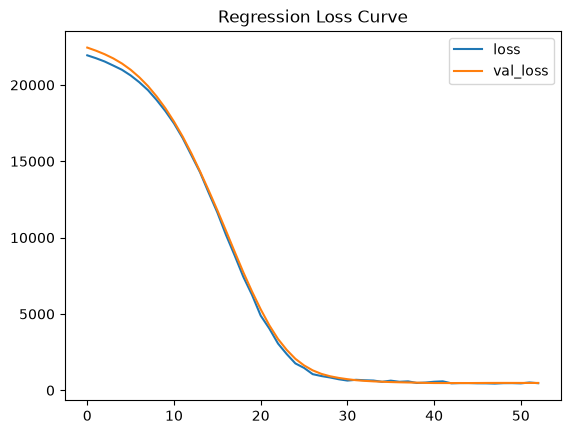

In [ ]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.title('Regression Loss Curve')
plt.legend()
plt.show()
# 훈련 / 검증 손실이 함께 감소하며 큰 차이를 보이지 않으므로 뚜렷한 과적합은 보이지 않음